# Sobol Visualisation — The Demographic Tide
Loads `sobol_results.npz` from `sobol_runner.py` and produces all Sobol figures and tables.

**Run order:** `python sobol_runner.py` → this notebook

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

from simulation_engine import YEARS, N_YEARS

PAL = {
    'navy': '#1B4F72', 'blue': '#2E86C1', 'sky': '#AED6F1', 'ice': '#D6EAF8',
    'amber': '#E67E22', 'brick': '#C0392B', 'fern': '#27AE60',
    'charcoal': '#2C3E50', 'slate': '#7F8C8D', 'silver': '#BDC3C7', 'cloud': '#F2F3F4',
}
mpl.rcParams.update({
    'figure.facecolor': PAL['cloud'], 'axes.facecolor': 'white',
    'axes.edgecolor': PAL['silver'], 'axes.labelcolor': PAL['charcoal'],
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlecolor': PAL['navy'],
    'axes.labelsize': 10, 'xtick.color': PAL['slate'], 'ytick.color': PAL['slate'],
    'axes.grid': False, 'legend.fontsize': 9, 'font.family': 'sans-serif',
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

def clean_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color(PAL['silver'])
    ax.spines['left'].set_color(PAL['silver'])

PROC = r'..\data\processed'
OUT = r'..\outputs'

data = np.load(f'{PROC}\sobol_results.npz')
print(f'Loaded sobol_results.npz: {len(data.files)} arrays')

# Quick verification
required_prefixes = ['overall_cross', 'overall_nf_2030', 'overall_pi_2050',
                     'full32_nf_2030', 'cond_cross', 'cond_nf_2050']
for prefix in required_prefixes:
    matches = [k for k in data.files if k.startswith(prefix)]
    if not matches:
        raise RuntimeError(f'FATAL: no arrays matching prefix {prefix}')
print(f'All required array groups present.')

HORIZON_YEARS = [2030, 2040, 2050]
overall_names = ['demo_u', 'inflow_shock', 'vol_multiplier', 'net_buyback_yield', 'M_base', 'passive_z', 'annual_return']
cond_names = ['demo_u', 'inflow_shock', 'vol_multiplier', 'net_buyback_yield', 'M_base', 'passive_z']
param_labels = ['Demographic\nscenario', 'Inflow\nshock', 'Voluntary\nwithdrawal',
                'Net buyback\nyield', 'Multiplier\n(M)', 'Passive share\npath', 'Market\nreturn']
cond_labels = param_labels[:6]


Loaded sobol_results.npz: 68 arrays
All required array groups present.


## Overall Sobol Indices (7 Parameters)


OVERALL SOBOL — NET FLOW AT 2030 ($B)
Parameter                  S1   ±   conf         ST   ±   conf
----------------------------------------------------------
vol_multiplier       0.481 ± 0.045   0.491 ± 0.030
annual_return        0.291 ± 0.029   0.300 ± 0.019
inflow_shock         0.215 ± 0.026   0.218 ± 0.015
demo_u               0.003 ± 0.004   0.003 ± 0.000
M_base               0.000 ± 0.000   0.000 ± 0.000
passive_z            -0.000 ± 0.000   0.000 ± 0.000
net_buyback_yield    0.000 ± 0.000   0.000 ± 0.000

OVERALL SOBOL — NET FLOW AT 2040 ($B)
Parameter                  S1   ±   conf         ST   ±   conf
----------------------------------------------------------
annual_return        0.872 ± 0.057   0.888 ± 0.042
vol_multiplier       0.074 ± 0.015   0.090 ± 0.009
inflow_shock         0.036 ± 0.013   0.038 ± 0.003
demo_u               0.002 ± 0.003   0.002 ± 0.000
M_base               0.000 ± 0.000   0.000 ± 0.000
passive_z            0.000 ± 0.000   0.000 ± 0.000
net_buyback_yi

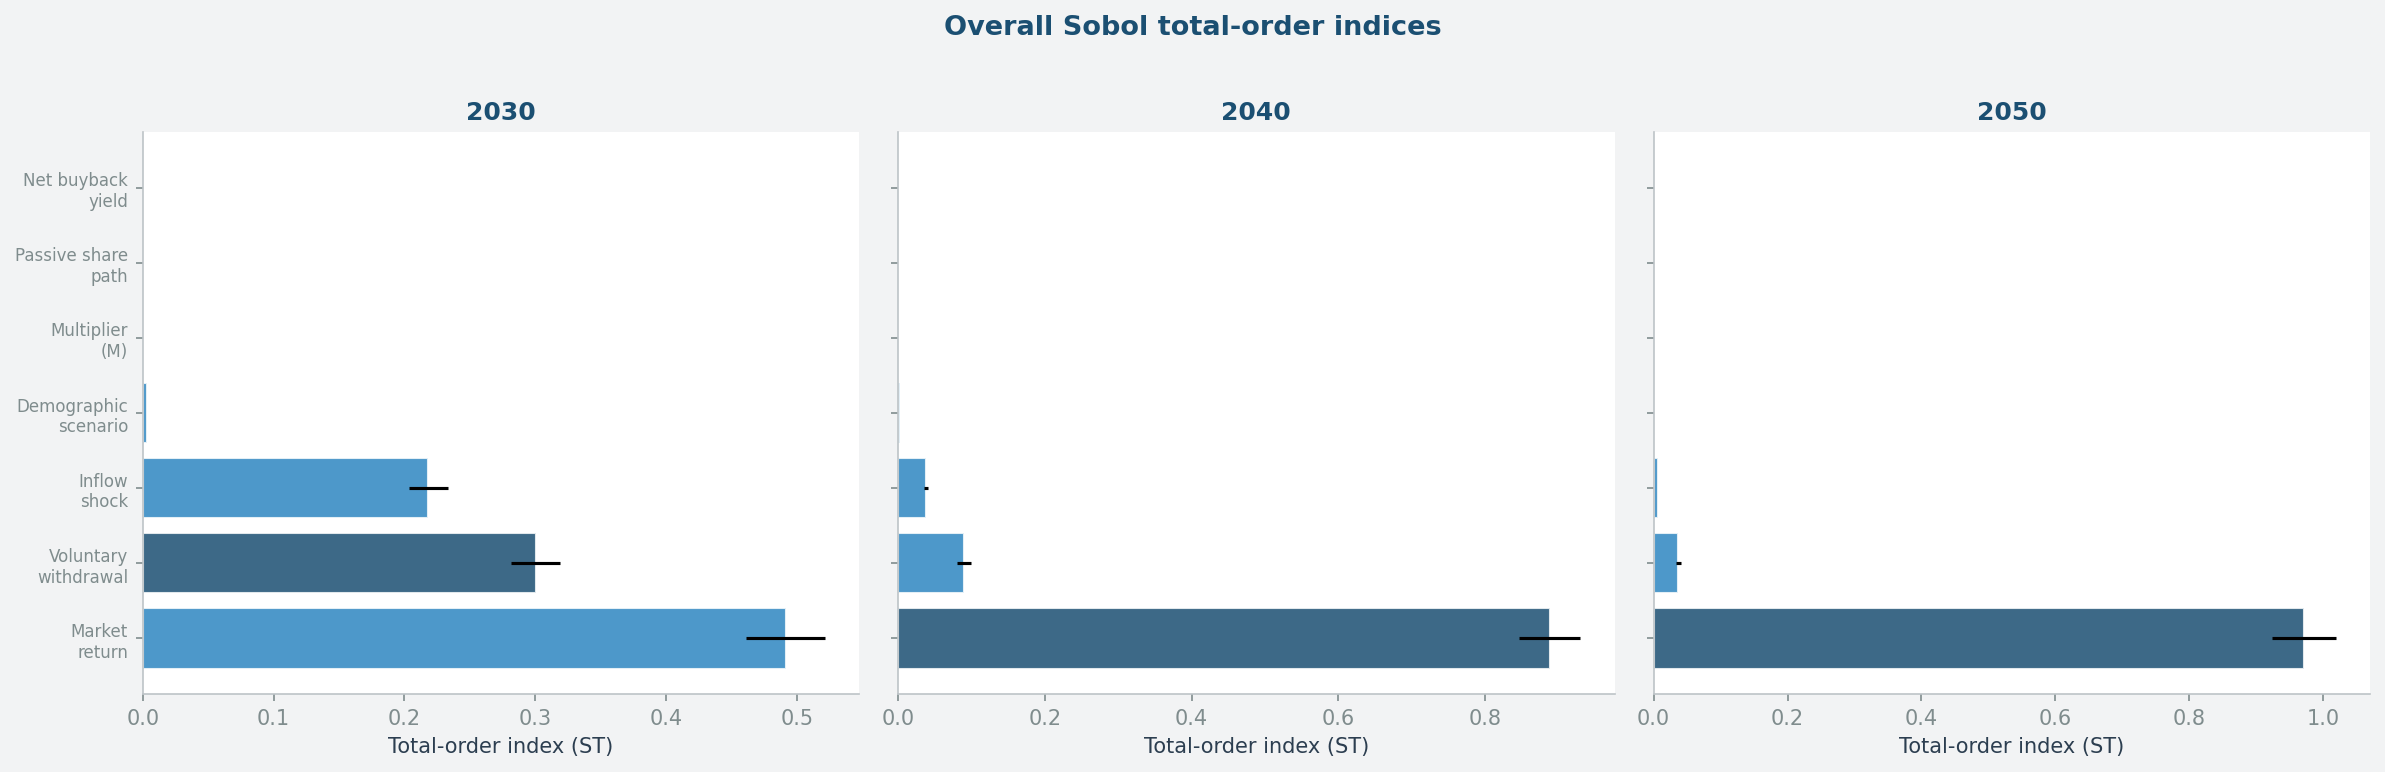

In [18]:
pm = chr(177)

for yr in HORIZON_YEARS:
    S1 = data[f'overall_nf_{yr}_S1']
    ST = data[f'overall_nf_{yr}_ST']
    S1c = data[f'overall_nf_{yr}_S1_conf']
    STc = data[f'overall_nf_{yr}_ST_conf']
    sorted_idx = np.argsort(-ST)
    print(f"\n{'='*70}")
    print(f'OVERALL SOBOL — NET FLOW AT {yr} ($B)')
    print(f"{'='*70}")
    print(f"{'Parameter':<20} {'S1':>8} {pm:>3} {'conf':>6}   {'ST':>8} {pm:>3} {'conf':>6}")
    print(f"{'-'*58}")
    for j in sorted_idx:
        print(f"{overall_names[j]:<20} {S1[j]:.3f} {pm} {S1c[j]:.3f}   {ST[j]:.3f} {pm} {STc[j]:.3f}")

# Summary
print(f"\n{'Year':>6}  {'Return ST':>12}  {'Top structural':>18}  {'Its ST':>8}")
for yr in HORIZON_YEARS:
    ST = data[f'overall_nf_{yr}_ST']
    top_struct = np.argmax(ST[:-1])
    print(f"  {yr:>4}     {ST[-1]:.3f}     {overall_names[top_struct]:>18}     {ST[top_struct]:.3f}")

# Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for k, yr in enumerate(HORIZON_YEARS):
    ax = axes[k]
    ST = data[f'overall_nf_{yr}_ST']
    STc = data[f'overall_nf_{yr}_ST_conf']
    sorted_idx = np.argsort(-ST)
    colors = [PAL['navy'] if overall_names[j]=='annual_return' else PAL['blue'] for j in sorted_idx]
    ax.barh(range(7), ST[sorted_idx], xerr=STc[sorted_idx], color=colors, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(7))
    ax.set_yticklabels([param_labels[j] for j in sorted_idx], fontsize=8)
    ax.set_title(f'{yr}', fontsize=12, fontweight='bold', color=PAL['navy'])
    ax.set_xlabel('Total-order index (ST)')
    clean_spines(ax)
plt.suptitle('Overall Sobol total-order indices', fontsize=13, fontweight='bold', color=PAL['navy'], y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}\\sobol_overall_multi_horizon.png', dpi=300, bbox_inches='tight')
plt.show()


## 32-Parameter Sobol: Individual Annual Returns

In [19]:
struct_names = ['inflow_shock', 'vol_multiplier', 'net_buyback_yield', 'M_base', 'passive_z', 'demo_u']

print(f"{'='*70}")
print('32-PARAMETER SOBOL — INDIVIDUAL ANNUAL RETURNS')
print(f"{'='*70}")

for yr in HORIZON_YEARS:
    S1 = data[f'full32_nf_{yr}_S1']
    ST = data[f'full32_nf_{yr}_ST']
    ret_S1 = S1[:26].sum()
    ret_ST = ST[:26].sum()
    old_ST = data[f'overall_nf_{yr}_ST'][-1]

    print(f'\n  {yr}:')
    print(f'    Aggregate return:  S1={ret_S1:.3f}  ST={ret_ST:.3f}')
    for j, name in enumerate(struct_names):
        if ST[26+j] > 0.01:
            print(f'    {name:<25} S1={S1[26+j]:.3f}  ST={ST[26+j]:.3f}')
    print(f'    7-param constant-return ST: {old_ST:.3f}')
    print(f'    32-param aggregate ST:      {ret_ST:.3f}')
    print(f'    Difference: {ret_ST - old_ST:+.3f}')
    print(f'    Sum S1 (all 32): {S1.sum():.3f}')


32-PARAMETER SOBOL — INDIVIDUAL ANNUAL RETURNS

  2030:
    Aggregate return:  S1=0.552  ST=0.597
    inflow_shock              S1=0.131  ST=0.131
    vol_multiplier            S1=0.281  ST=0.302
    7-param constant-return ST: 0.300
    32-param aggregate ST:      0.597
    Difference: +0.297
    Sum S1 (all 32): 0.965

  2040:
    Aggregate return:  S1=0.829  ST=0.998
    inflow_shock              S1=0.039  ST=0.038
    vol_multiplier            S1=0.051  ST=0.076
    7-param constant-return ST: 0.888
    32-param aggregate ST:      0.998
    Difference: +0.110
    Sum S1 (all 32): 0.920

  2050:
    Aggregate return:  S1=0.793  ST=1.137
    inflow_shock              S1=0.011  ST=0.012
    vol_multiplier            S1=0.019  ST=0.034
    7-param constant-return ST: 0.971
    32-param aggregate ST:      1.137
    Difference: +0.166
    Sum S1 (all 32): 0.823


## Conditional Sobol (Return Fixed at 10%)


CONDITIONAL SOBOL — NET FLOW AT 2030 (return = 9.9%)
Parameter                  S1   ±   conf         ST   ±   conf
----------------------------------------------------------
vol_multiplier       0.680 ± 0.041   0.680 ± 0.035
inflow_shock         0.315 ± 0.032   0.315 ± 0.018
demo_u               0.005 ± 0.004   0.005 ± 0.000
M_base               -0.000 ± 0.000   0.000 ± 0.000
passive_z            -0.000 ± 0.000   0.000 ± 0.000
net_buyback_yield    0.000 ± 0.000   0.000 ± 0.000
Sum S1: 1.000

CONDITIONAL SOBOL — NET FLOW AT 2040 (return = 9.9%)
Parameter                  S1   ±   conf         ST   ±   conf
----------------------------------------------------------
vol_multiplier       0.590 ± 0.040   0.590 ± 0.034
inflow_shock         0.385 ± 0.032   0.386 ± 0.022
demo_u               0.024 ± 0.009   0.024 ± 0.002
M_base               -0.000 ± 0.000   0.000 ± 0.000
passive_z            0.000 ± 0.000   0.000 ± 0.000
net_buyback_yield    0.000 ± 0.000   0.000 ± 0.000
Sum S1: 0.999

COND

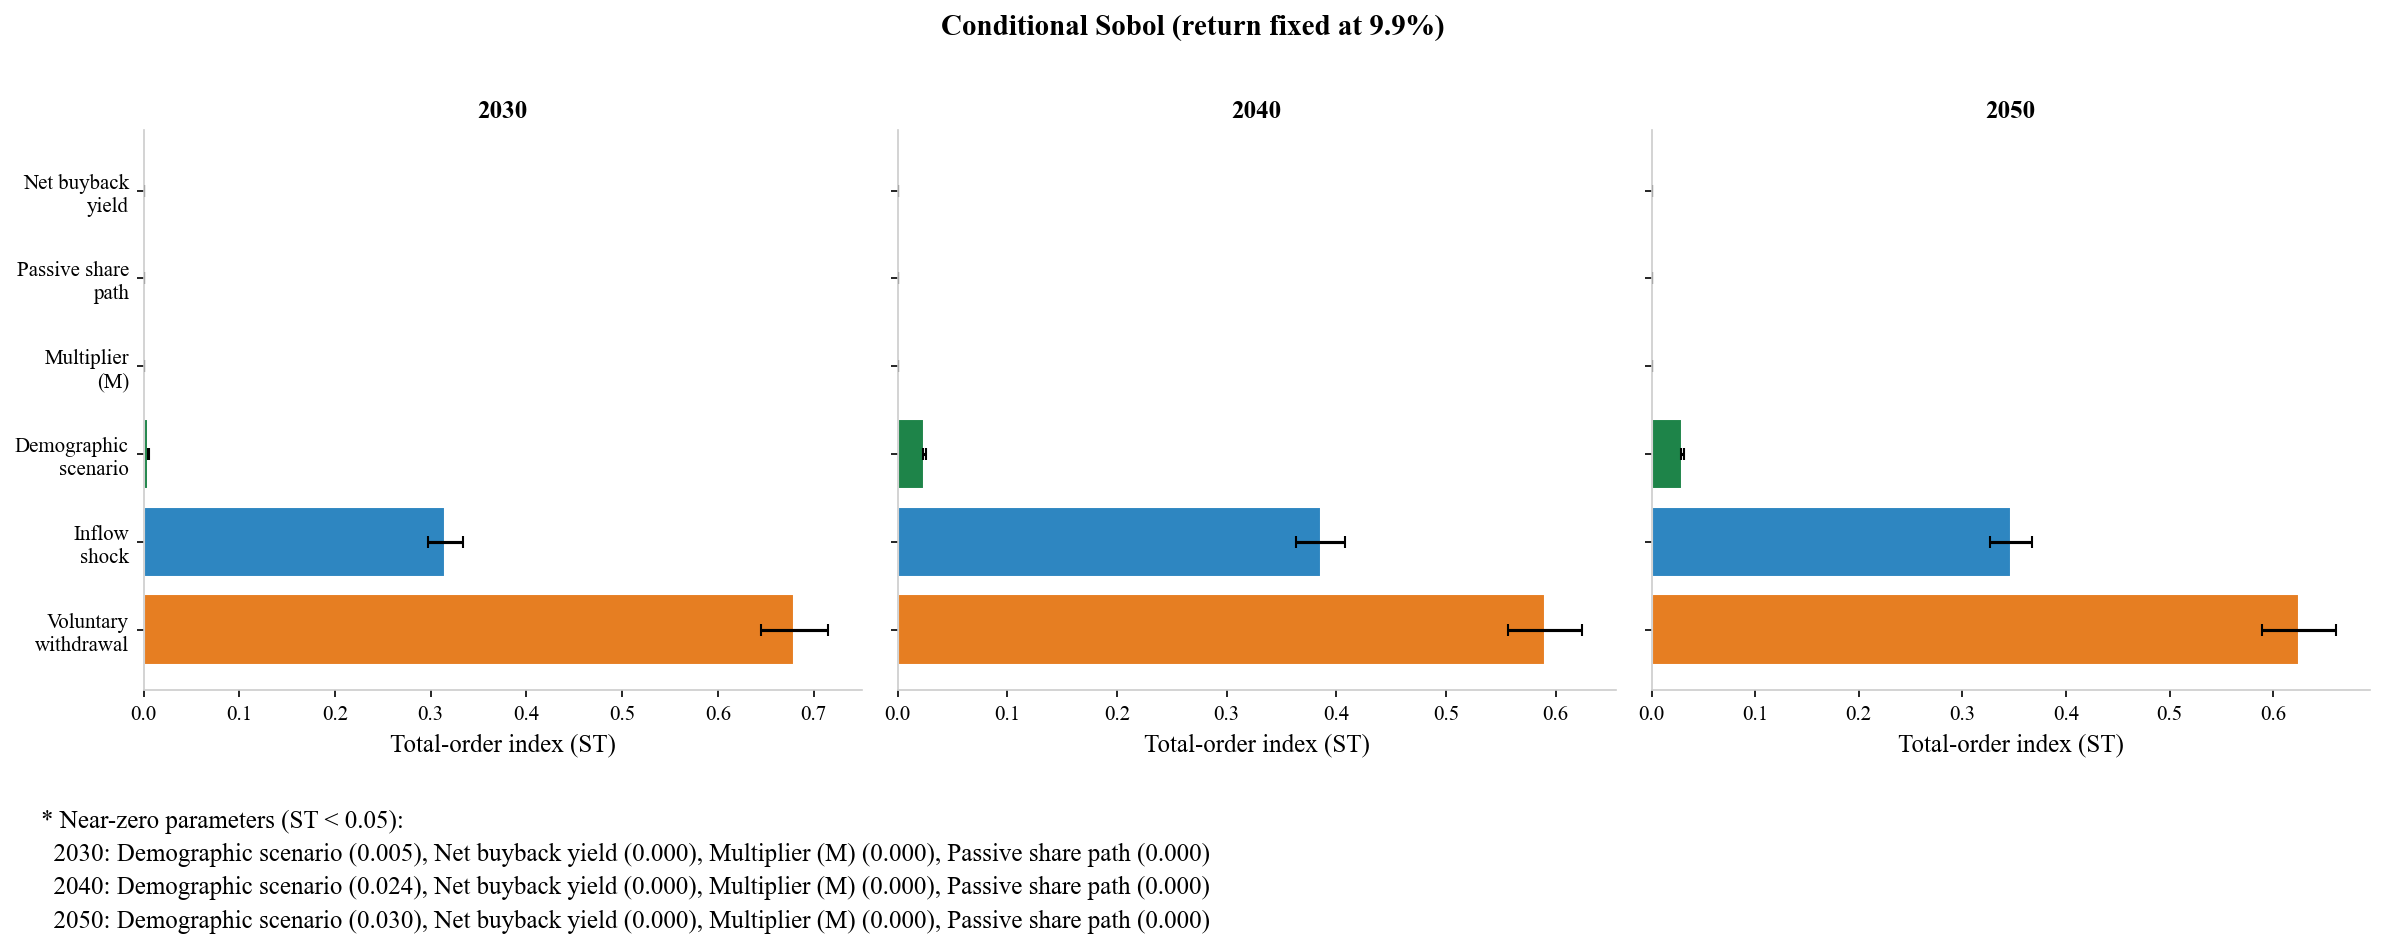

In [20]:
# ── Conditional Sobol (return fixed at 9.9%) ─────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

pm = chr(177)

for yr in HORIZON_YEARS:
    S1 = data[f'cond_nf_{yr}_S1']
    ST = data[f'cond_nf_{yr}_ST']
    S1c = data[f'cond_nf_{yr}_S1_conf']
    STc = data[f'cond_nf_{yr}_ST_conf']
    sorted_idx = np.argsort(-ST)
    print(f"\n{'='*70}")
    print(f'CONDITIONAL SOBOL — NET FLOW AT {yr} (return = 9.9%)')
    print(f"{'='*70}")
    print(f"{'Parameter':<20} {'S1':>8} {pm:>3} {'conf':>6}   {'ST':>8} {pm:>3} {'conf':>6}")
    print(f"{'-'*58}")
    for j in sorted_idx:
        print(f"{cond_names[j]:<20} {S1[j]:.3f} {pm} {S1c[j]:.3f}   {ST[j]:.3f} {pm} {STc[j]:.3f}")
    print(f"Sum S1: {S1.sum():.3f}")

COND_COLORS = {
    'vol_multiplier': '#E67E22',
    'inflow_shock': '#2E86C1',
    'demo_u': '#1E8449',
    'M_base': '#B0B3B8',
    'passive_z': '#B0B3B8',
    'net_buyback_yield': '#B0B3B8',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, facecolor='white')

for k, yr in enumerate(HORIZON_YEARS):
    ax = axes[k]
    ax.set_facecolor('white')
    ST = data[f'cond_nf_{yr}_ST']
    STc = data[f'cond_nf_{yr}_ST_conf']
    sorted_idx = np.argsort(-ST)
    colors = [COND_COLORS.get(cond_names[j], '#B0B3B8') for j in sorted_idx]
    ax.barh(range(6), ST[sorted_idx], xerr=STc[sorted_idx],
            color=colors, edgecolor='white', capsize=3)
    ax.set_yticks(range(6))
    ax.set_yticklabels([cond_labels[j] for j in sorted_idx], fontsize=10)
    ax.set_title(f'{yr}', fontsize=12, fontweight='bold', color='black')
    ax.set_xlabel('Total-order index (ST)', fontsize=12, color='black')
    ax.tick_params(colors='black', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(False)

footnote_lines = ['* Near-zero parameters (ST < 0.05):']
for yr in HORIZON_YEARS:
    ST = data[f'cond_nf_{yr}_ST']
    small = [(cond_labels[i].replace('\n', ' '), ST[i])
             for i in range(6) if ST[i] < 0.05]
    if small:
        pairs = ', '.join([f'{n} ({v:.3f})' for n, v in small])
        footnote_lines.append(f'  {yr}: {pairs}')

fig.text(0.02, -0.04, '\n'.join(footnote_lines),
         fontsize=12, color='black', ha='left', va='top', linespacing=1.5)

plt.suptitle('Conditional Sobol (return fixed at 9.9%)',
             fontsize=14, fontweight='bold', color='black', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}\\sobol_conditional_multi_horizon.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## Price Impact Sobol

In [21]:
pm = chr(177)

for yr in HORIZON_YEARS:
    S1 = data[f'overall_pi_{yr}_S1']
    ST = data[f'overall_pi_{yr}_ST']
    S1c = data[f'overall_pi_{yr}_S1_conf']
    STc = data[f'overall_pi_{yr}_ST_conf']
    sorted_idx = np.argsort(-ST)
    print(f"{'='*70}")
    print(f'PRICE IMPACT SOBOL — {yr}')
    print(f"{'='*70}")
    for j in sorted_idx:
        if abs(ST[j]) > 0.001:
            print(f"{overall_names[j]:<20} S1={S1[j]:.3f} {pm} {S1c[j]:.3f}   ST={ST[j]:.3f} {pm} {STc[j]:.3f}")

# Validation
for yr in HORIZON_YEARS:
    ST = data[f'overall_pi_{yr}_ST']
    m_st = ST[overall_names.index('M_base')]
    p_st = ST[overall_names.index('passive_z')]
    print(f'{yr}: M_base ST={m_st:.3f} ({"PASS" if m_st > 0 else "CHECK"}), '
          f'passive_z ST={p_st:.3f} ({"PASS" if p_st < 0.01 else "CHECK"})')


PRICE IMPACT SOBOL — 2030
annual_return        S1=0.473 ± 0.046   ST=0.514 ± 0.038
vol_multiplier       S1=0.272 ± 0.028   ST=0.285 ± 0.023
inflow_shock         S1=0.133 ± 0.026   ST=0.146 ± 0.011
M_base               S1=0.062 ± 0.020   ST=0.109 ± 0.012
demo_u               S1=0.002 ± 0.003   ST=0.002 ± 0.000
PRICE IMPACT SOBOL — 2040
annual_return        S1=0.860 ± 0.063   ST=0.930 ± 0.061
M_base               S1=0.013 ± 0.016   ST=0.061 ± 0.009
inflow_shock         S1=0.028 ± 0.014   ST=0.045 ± 0.005
vol_multiplier       S1=0.028 ± 0.009   ST=0.029 ± 0.002
demo_u               S1=0.001 ± 0.004   ST=0.004 ± 0.000
passive_z            S1=0.002 ± 0.002   ST=0.001 ± 0.000
PRICE IMPACT SOBOL — 2050
annual_return        S1=0.903 ± 0.083   ST=0.971 ± 0.058
M_base               S1=0.009 ± 0.015   ST=0.057 ± 0.011
inflow_shock         S1=0.012 ± 0.012   ST=0.027 ± 0.004
vol_multiplier       S1=0.007 ± 0.005   ST=0.008 ± 0.001
demo_u               S1=-0.002 ± 0.004   ST=0.006 ± 0.001
2030: M_b

PRICE IMPACT SOBOL — 2030
Parameter                  S1   ±   conf         ST   ±   conf
----------------------------------------------------------
demo_u               0.002 ± 0.003   0.002 ± 0.000
inflow_shock         0.133 ± 0.026   0.146 ± 0.011
vol_multiplier       0.272 ± 0.028   0.285 ± 0.023
net_buyback_yield    0.000 ± 0.000   0.000 ± 0.000
M_base               0.062 ± 0.020   0.109 ± 0.012
passive_z            0.001 ± 0.001   0.000 ± 0.000
annual_return        0.473 ± 0.046   0.514 ± 0.038
PRICE IMPACT SOBOL — 2040
Parameter                  S1   ±   conf         ST   ±   conf
----------------------------------------------------------
demo_u               0.001 ± 0.004   0.004 ± 0.000
inflow_shock         0.028 ± 0.014   0.045 ± 0.005
vol_multiplier       0.028 ± 0.009   0.029 ± 0.002
net_buyback_yield    0.000 ± 0.000   0.000 ± 0.000
M_base               0.013 ± 0.016   0.061 ± 0.009
passive_z            0.002 ± 0.002   0.001 ± 0.000
annual_return        0.860 ± 0.063   0.93

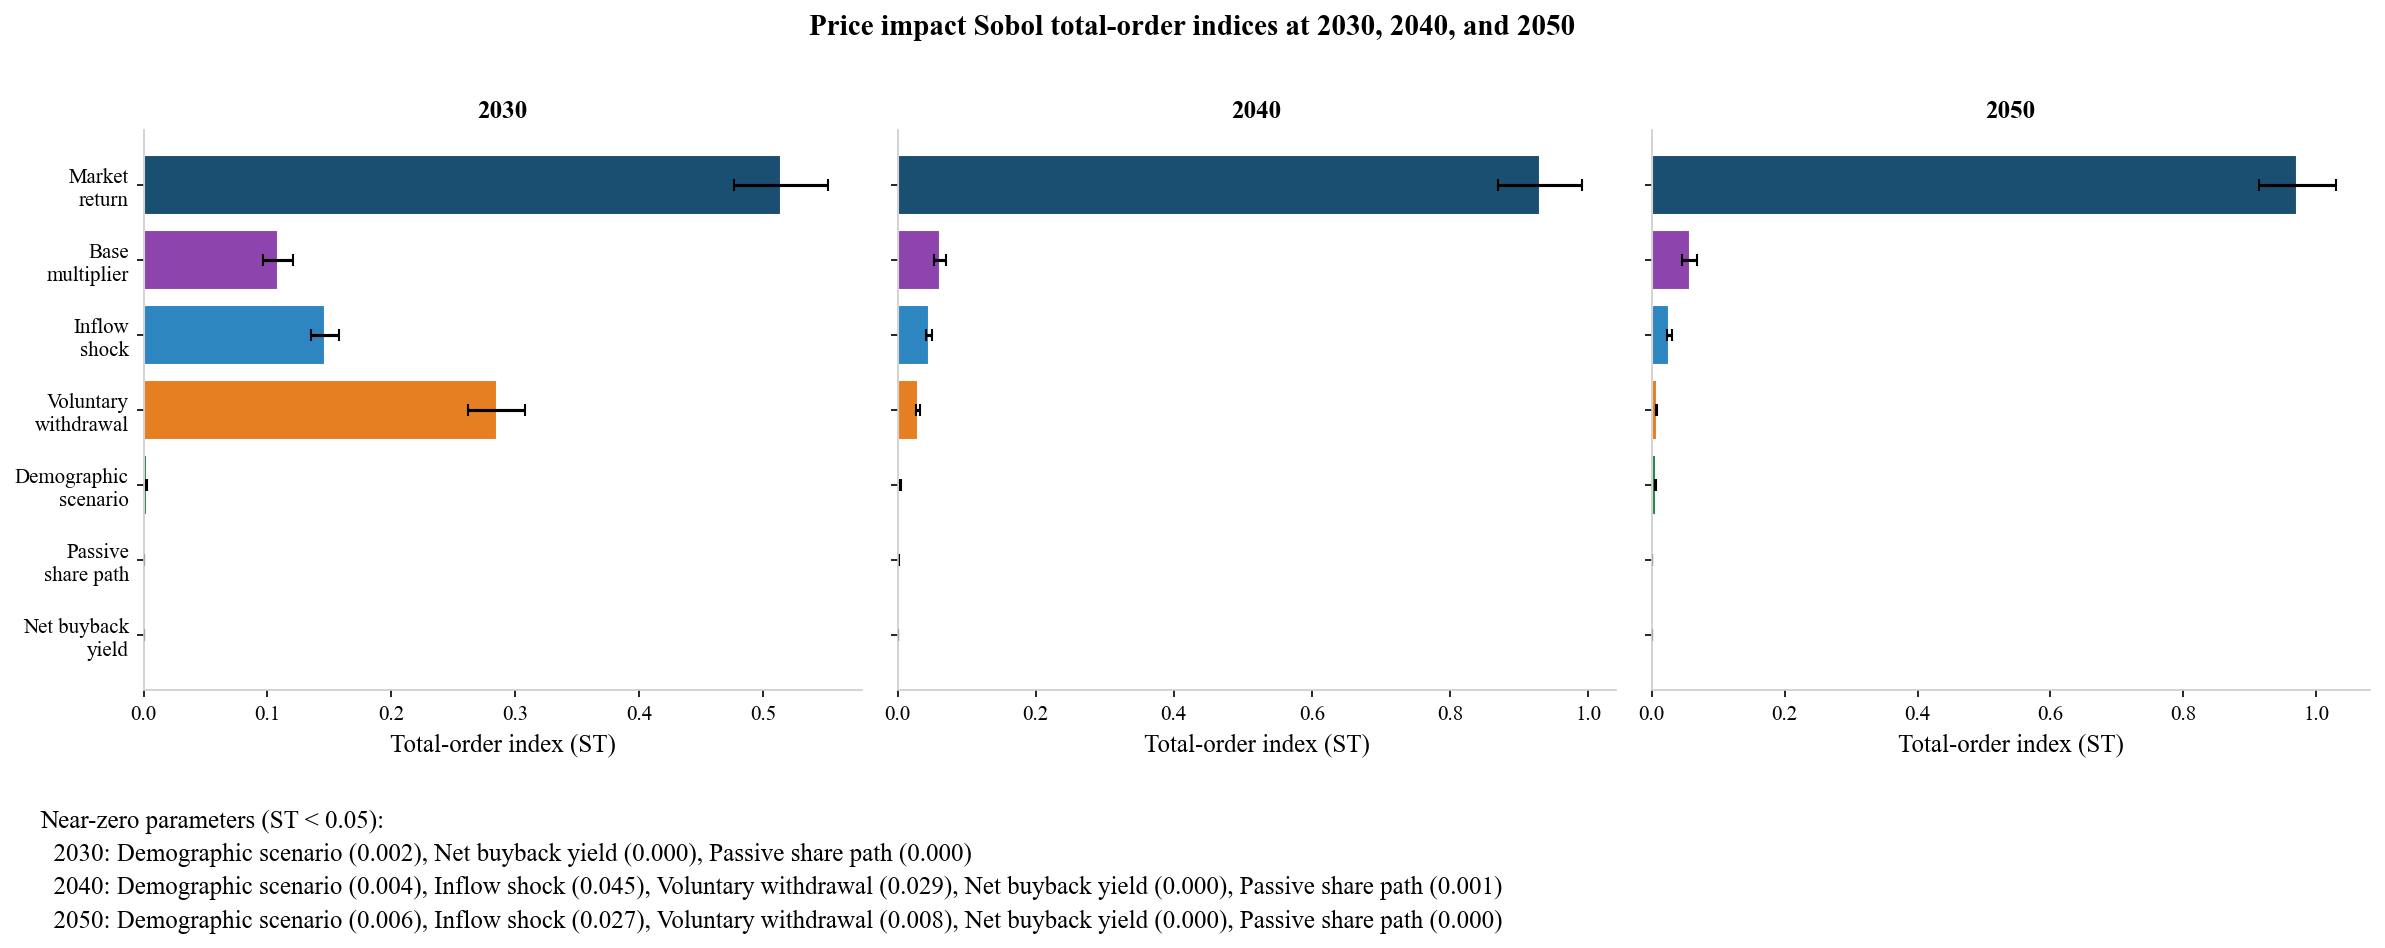

In [22]:
# ── Price Impact Sobol ───────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

pm = chr(177)

for yr in HORIZON_YEARS:
    S1 = data[f'overall_pi_{yr}_S1']
    ST = data[f'overall_pi_{yr}_ST']
    S1c = data[f'overall_pi_{yr}_S1_conf']
    STc = data[f'overall_pi_{yr}_ST_conf']
    print(f"{'='*70}")
    print(f'PRICE IMPACT SOBOL — {yr}')
    print(f"{'='*70}")
    print(f"{'Parameter':<20} {'S1':>8} {pm:>3} {'conf':>6}   {'ST':>8} {pm:>3} {'conf':>6}")
    print(f"{'-'*58}")
    for j in range(7):
        print(f"{overall_names[j]:<20} {S1[j]:.3f} {pm} {S1c[j]:.3f}   {ST[j]:.3f} {pm} {STc[j]:.3f}")

# Fixed order — biggest to smallest based on typical ranking
FIXED_ORDER = ['annual_return', 'M_base', 'inflow_shock', 'vol_multiplier',
               'demo_u', 'passive_z', 'net_buyback_yield']
fixed_idx = [overall_names.index(n) for n in FIXED_ORDER]

PI_COLORS = {
    'annual_return': '#1B4F72',
    'vol_multiplier': '#E67E22',
    'inflow_shock': '#2E86C1',
    'M_base': '#8E44AD',
    'demo_u': '#1E8449',
    'passive_z': '#B0B3B8',
    'net_buyback_yield': '#B0B3B8',
}

pi_labels = {
    'annual_return': 'Market\nreturn',
    'vol_multiplier': 'Voluntary\nwithdrawal',
    'inflow_shock': 'Inflow\nshock',
    'M_base': 'Base\nmultiplier',
    'demo_u': 'Demographic\nscenario',
    'passive_z': 'Passive\nshare path',
    'net_buyback_yield': 'Net buyback\nyield',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, facecolor='white')

for k, yr in enumerate(HORIZON_YEARS):
    ax = axes[k]
    ax.set_facecolor('white')
    ST = data[f'overall_pi_{yr}_ST']
    STc = data[f'overall_pi_{yr}_ST_conf']
    # Reverse so biggest is at bottom (reads top to bottom naturally)
    display_idx = list(reversed(fixed_idx))
    colors = [PI_COLORS[FIXED_ORDER[6 - i]] for i in range(7)]
    labels = [pi_labels[FIXED_ORDER[6 - i]] for i in range(7)]
    vals = [ST[j] for j in display_idx]
    errs = [STc[j] for j in display_idx]
    ax.barh(range(7), vals, xerr=errs,
            color=colors, edgecolor='white', capsize=3)
    ax.set_yticks(range(7))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_title(f'{yr}', fontsize=12, fontweight='bold', color='black')
    ax.set_xlabel('Total-order index (ST)', fontsize=12, color='black')
    ax.tick_params(colors='black', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(False)

footnote_lines = ['Near-zero parameters (ST < 0.05):']
for yr in HORIZON_YEARS:
    ST = data[f'overall_pi_{yr}_ST']
    small = [(pi_labels[overall_names[i]].replace('\n', ' '), ST[i])
             for i in range(7) if ST[i] < 0.05]
    if small:
        pairs = ', '.join([f'{n} ({v:.3f})' for n, v in small])
        footnote_lines.append(f'  {yr}: {pairs}')

fig.text(0.02, -0.04, '\n'.join(footnote_lines),
         fontsize=12, color='black', ha='left', va='top', linespacing=1.5)

plt.suptitle('Price impact Sobol total-order indices at 2030, 2040, and 2050',
             fontsize=14, fontweight='bold', color='black', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}\\sobol_price_impact_multi_horizon.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()


57-PARAM SOBOL — NET FLOW AT 2030
Parameter                  ST     conf
----------------------------------------
Market return           0.541    0.017
Voluntary withdrawal    0.375    0.022
Inflow shock            0.115    0.008
Demographic scenario    0.002    0.000
Base multiplier         0.000    0.000
Passive share path      0.000    0.000
Net buyback yield       0.000    0.000

57-PARAM SOBOL — NET FLOW AT 2040
Parameter                  ST     conf
----------------------------------------
Market return           0.920    0.023
Voluntary withdrawal    0.165    0.017
Inflow shock            0.027    0.002
Demographic scenario    0.002    0.000
Base multiplier         0.000    0.000
Passive share path      0.000    0.000
Net buyback yield       0.000    0.000

57-PARAM SOBOL — NET FLOW AT 2050
Parameter                  ST     conf
----------------------------------------
Market return           1.064    0.032
Voluntary withdrawal    0.099    0.011
Inflow shock            0.007  

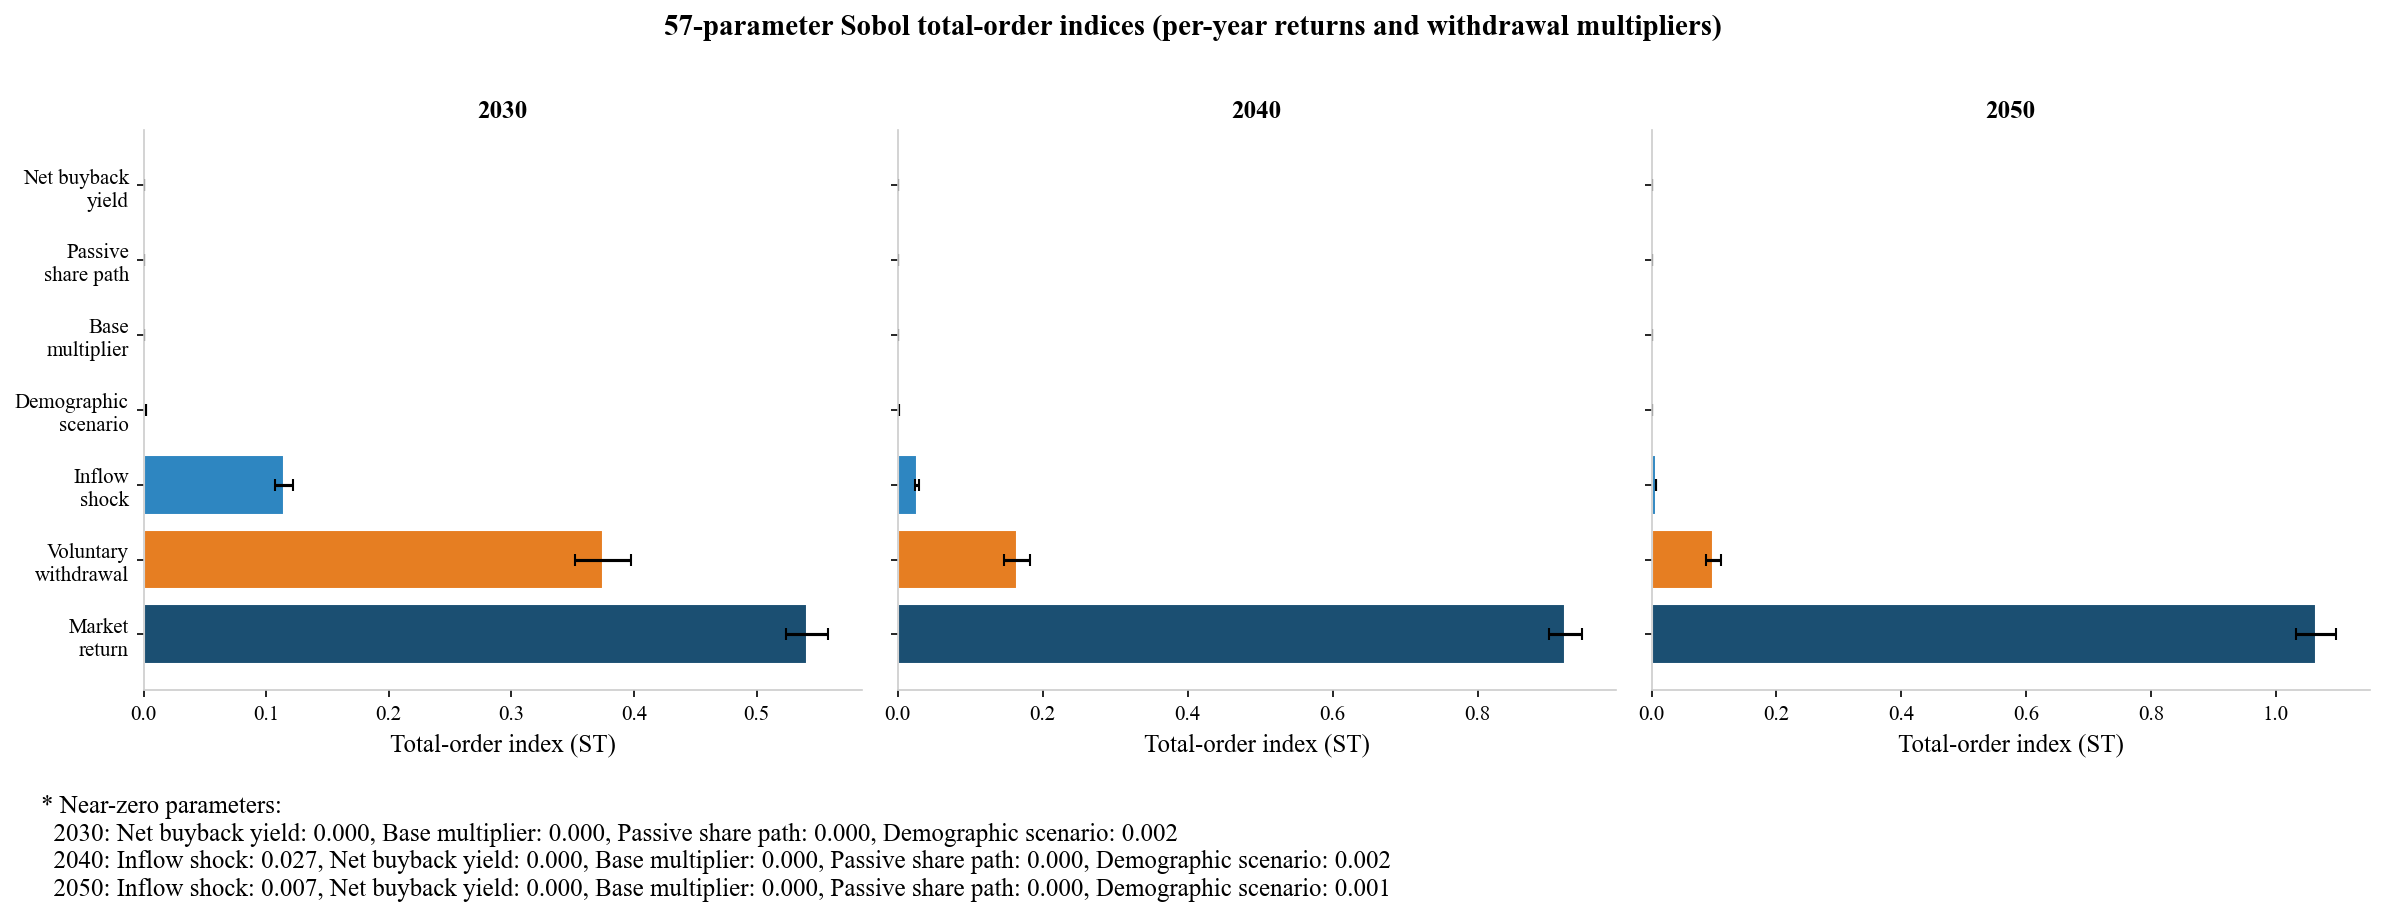

In [23]:
# ── 57-Parameter Sobol: Aggregate by parameter group ────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

param_labels_57 = [
    'Market\nreturn',
    'Voluntary\nwithdrawal',
    'Inflow\nshock',
    'Net buyback\nyield',
    'Base\nmultiplier',
    'Passive\nshare path',
    'Demographic\nscenario',
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, facecolor='white')

for k, yr in enumerate(HORIZON_YEARS):
    ax = axes[k]
    ax.set_facecolor('white')
    ST = data[f'full57_nf_{yr}_ST']
    STc = data[f'full57_nf_{yr}_ST_conf']
    
    agg_ST = np.array([
        ST[:26].sum(),
        ST[26:52].sum(),
        ST[52],
        ST[53],
        ST[54],
        ST[55],
        ST[56],
    ])
    
    agg_STc = np.array([
        np.sqrt((STc[:26]**2).sum()),
        np.sqrt((STc[26:52]**2).sum()),
        STc[52],
        STc[53],
        STc[54],
        STc[55],
        STc[56],
    ])
    
    sorted_idx = np.argsort(-agg_ST)
    colors = [PAL['navy'] if i == 0 else PAL['amber'] if i == 1 
              else PAL['blue'] for i in sorted_idx]
    
    ax.barh(range(7), agg_ST[sorted_idx], xerr=agg_STc[sorted_idx],
            color=colors, edgecolor='white', capsize=3)
    ax.set_yticks(range(7))
    ax.set_yticklabels([param_labels_57[j] for j in sorted_idx], fontsize=10)
    ax.set_title(f'{yr}', fontsize=12, fontweight='bold', color='black')
    ax.set_xlabel('Total-order index (ST)', fontsize=12, color='black')
    ax.tick_params(colors='black', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(False)
    
    print(f'\n57-PARAM SOBOL — NET FLOW AT {yr}')
    print(f'{"Parameter":<20} {"ST":>8} {"conf":>8}')
    print('-' * 40)
    for j in sorted_idx:
        print(f'{param_labels_57[j].replace(chr(10), " "):<20} {agg_ST[j]:>8.3f} {agg_STc[j]:>8.3f}')

plt.suptitle('57-parameter Sobol total-order indices (per-year returns and withdrawal multipliers)',
             fontsize=14, fontweight='bold', color='black', y=1.02)
plt.tight_layout()
# Collect near-zero parameters for footnote
footnote_lines = ['* Near-zero parameters:']
for yr in HORIZON_YEARS:
    ST = data[f'full57_nf_{yr}_ST']
    agg_ST = np.array([
        ST[:26].sum(), ST[26:52].sum(),
        ST[52], ST[53], ST[54], ST[55], ST[56],
    ])
    small = [(param_labels_57[i].replace('\n', ' '), agg_ST[i]) 
             for i in range(7) if agg_ST[i] < 0.05]
    small_str = ', '.join([f'{n}: {v:.3f}' for n, v in small])
    footnote_lines.append(f'  {yr}: {small_str}')

footnote = '\n'.join(footnote_lines)
fig.text(0.02, -0.02, footnote,
         fontsize=12, color='black', ha='left', va='top')
plt.savefig(f'{OUT}\\sobol_57param_multi_horizon.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()